# US equities panel: predicting a week ahead instead of five days ahead

The three sequence notebooks before this one - [`09_dl_nlinear`](09_dl_nlinear.ipynb),
[`10_dl_lstm`](10_dl_lstm.ipynb) and [`11_dl_tsmixer`](11_dl_tsmixer.ipynb), the last of which
is offered rather than run - read a window of daily rows and predict a return five sessions
ahead. That is a **multi-step** problem: the
quantity being predicted spans five periods of the grid the model reads. This notebook changes
the grid rather than the models, and asks whether that alone is worth anything.

**Sampling on Fridays makes the same label a one-step problem.** `fwd_ret_5d` is the return over
the next five *sessions*, and a full trading week holds exactly five, so on a Friday-only grid
each row's label lands on about the next row. Nothing about the label changed; what changed is
how many steps of the model's own grid it spans. Two things follow, and they pull in opposite
directions. A one-step target avoids the error compounding that makes a multi-step forecast
progressively vaguer, and the reader should expect that to help. Against it, subsampling to one
day in five throws away four fifths of the rows, and a sequence model on a smaller sample is a
weaker fit. The experiment is worth running because neither effect is obviously larger.

**Two formulations of the same task are compared.** Both read a **lookback** window of the
twelve most recent weekly feature vectors for a stock - about three months - and both are scored
on the same rows over the same horizon.

- **Direct regression** treats the window as fixed-length input to a model whose output is one
  number, the return. `lstm_h64` is a two-layer recurrent network that consumes the window one
  week at a time and carries a hidden state forward; `nlinear` normalizes the window by its last
  value and applies a single linear map. Neither has any notion that its output is a future
  value of one of its inputs.
- **One-step forecasting** treats the window as the history of a time series and asks for its
  next value. `NBEATSModel`, from the Darts library, is built for that formulation: a stack of
  blocks that each fit a piece of the signal and pass the remainder to the next.
  `darts_output_chunk_length=1` is what makes it predict a single week rather than a sequence.

The comparison is therefore between two ways of writing down the same prediction, at a frequency
where the second is well posed. On a daily grid it would not be: N-BEATS asked for five days
would compound its own output four times.

**What the reader should carry away is the reframing, not this panel's numbers.** Whether a
weekly grid helps depends on how much history the panel has and how strongly the signal decays,
and both differ by market.

**Learning objectives.** By the end of this notebook you will be able to:

- Say what makes a prediction one-step rather than multi-step, and why that is a property of the
  sampling grid rather than of the label.
- State the two costs of subsampling a daily panel to weekly and say which one a longer history
  would relieve.
- Distinguish direct regression from forecasting as two formulations of one prediction, and say
  what each assumes about the relationship between input and output.
- Explain why a walk-forward fold has to be resolved from the label file rather than written into
  the notebook, and what a hand-written window would be free to do.
- Say what a training identity has to cover before a run may be skipped as already complete, and
  what goes wrong when the feature set is outside it.

**Book reference**: Chapter 13, Section 13.9. Table 13.5 reports the results this notebook
produces.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices,
and [`02_labels`](02_labels.ipynb) has written `fwd_ret_5d`.

**What it writes**: one training run and one validation prediction set per configuration, in
`run_log/registry.db` and under `run_log/training/`. These predictions sit on a Friday grid and
are deliberately **not** entered into the canonical backtest pool that
[`16_backtest`](16_backtest.ipynb) ranks: the daily models it ranks are scored on every session,
and a Friday-only series competing against them on the same label would be compared on a
different set of decision dates rather than on a different model.

In [1]:
"""Weekly-frequency sequence models: direct regression against one-step forecasting."""

'Weekly-frequency sequence models: direct regression against one-step forecasting.'

In [2]:
import gc
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch
from IPython.display import display

from case_studies.utils.cv_window import modeling_fold_boundaries
from case_studies.utils.deep_learning import run_dl_cv
from case_studies.utils.registry import (
    load_prediction_metrics,
    load_prediction_sets,
    load_training_runs,
)
from utils.artifact_specs import load_setup_config, resolve_label_buffer
from utils.modeling import (
    RANDOM_SEED,
    build_modeling_input_lineage,
    reduce_to_top_entities,
    seed_everything,
)
from utils.paths import get_case_study_dir
from utils.style import (
    COLORS,
    FIGSIZE,
    add_message_title,
    ml4t_palette,
    show_with_alt,
)

## The values a run can be given

What each one decides:

- **`LOOKBACK`** is how many weekly observations a model sees before predicting. Twelve is about
  three months, which is long enough to carry a quarter's momentum and short enough that a stock
  needs only twelve weeks of history before it contributes any training window at all.
- **`N_EPOCHS`** is how many passes the fit makes over its training rows. Fifty rather than the
  daily notebooks' longer schedules, because a Friday grid holds a fifth of the rows and a pass
  over it is a fifth of the gradient steps.
- **`MAX_FOLDS`** takes that many of the case study's walk-forward folds, evenly spaced and
  always including the earliest and the most recent. Four rather than all sixteen: this notebook
  fits four sequence models and the reframing it tests shows up across the sample's span rather
  than in the density of folds along it.
- **`MAX_TRAIN_SEQUENCES`** caps how many lookback windows one fold contributes. A cap is what
  keeps a fold's memory bounded on a three-thousand-name panel; it is lower here than in the
  daily notebooks because a weekly grid yields fewer windows to begin with.
- **`BATCH_SIZE`** is how many windows a gradient step averages over. It affects speed and the
  noise in each step, not what the model can represent.
- **`MAX_SYMBOLS`** caps the universe, taking the stocks with the most rows. Zero, the default,
  keeps all of them.
- **`FORCE_RETRAIN`** discards fitted state and refits configurations the registry already holds
  as complete. Leave it off unless the identity below has changed in a way the registry cannot
  see.

In [3]:
CASE_STUDY_ID = "us_equities_panel"
PRIMARY_LABEL = "fwd_ret_5d"
NOTEBOOK = "12_dl_weekly"

MAX_TRAIN_SEQUENCES = 200_000
# Sessions the label looks ahead, which is what makes a Friday grid one-step. Read from the
# label's own name rather than typed, so a different horizon cannot leave this behind.
LABEL_HORIZON_SESSIONS = int(PRIMARY_LABEL.rsplit("_", 1)[1].rstrip("d"))

In [4]:
BATCH_SIZE = 2048
LOOKBACK = 12
MAX_SYMBOLS = 0
FORCE_RETRAIN = False
PREDICTION_SPLIT = "validation"
N_EPOCHS = 50
MAX_FOLDS = 4

In [5]:
seed_everything(RANDOM_SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
SAVE_ROOT = CASE_DIR / "run_log" / "training" / "deep_learning" / NOTEBOOK
PYTORCH_SAVE_DIR = SAVE_ROOT / "pytorch"
DARTS_SAVE_DIR = SAVE_ROOT / "darts"
if FORCE_RETRAIN and SAVE_ROOT.exists():
    shutil.rmtree(SAVE_ROOT)
PYTORCH_SAVE_DIR.mkdir(parents=True, exist_ok=True)
DARTS_SAVE_DIR.mkdir(parents=True, exist_ok=True)

Device: cuda


## Subsampling the panel to a Friday grid

The daily features and labels are subsampled to Fridays, so `fwd_ret_5d` becomes a
one-step-ahead target: each row's window runs to about the next row's date.

**The windows are mostly, not entirely, non-overlapping, and the label is why.**
`02_labels` resolves `fwd_ret_5d` five *sessions* ahead. A full trading week holds exactly
five sessions, so a Friday's window closes on the next Friday. A week carrying a market
holiday holds four, so the fifth session falls on the Monday after that Friday and the
window overlaps the next observation's by a session. The cell below counts how often each
case occurs, on the label file's own session index rather than on a figure written down
here - the rate is a property of the exchange calendar, so it moves if the span does.

An overlap is usually one session and is not always: a week with one closure pushes the fifth
session to the Monday after the next Friday, and a span with two closures can push it further.
The printed distribution is what says how far, and it is worth reading rather than assuming,
because the length of an overlap is the size of the dependence it introduces.

The overlap is described rather than removed because the alternative that closes it exactly -
sampling every fifth session - drifts across weekdays and produces a cadence nobody trades. A
Friday grid is a week as a trader keeps it, and the price of that is the overlap counted above.

What it costs is the mechanical autocorrelation an overlapping window induces, on the share of
weeks the cell reports. That share is small enough to leave the one-step formulation intact and
too large to describe the windows as non-overlapping.

Non-overlap would not buy independence in any case. Returns cluster in volatility and share
a market factor across the cross-section, so what non-overlap removes is the correlation the
construction itself imposes, not the dependence in the data.

The cell below counts how often each case occurs. Each Friday's window closes on the fifth
session after that Friday, and the question is where that session falls relative to the next
one. Zero is an exact fit;
a positive distance is an overlap of that many sessions; a negative one means the window closed
before the next Friday, which happens when that Friday is itself a holiday and the label file
carries no row for it. The whole distribution is reported rather than a single count, because
the size of an overlap is the size of the dependence it introduces. The session index comes
from the label file, so this is a statement about the data this notebook reads.

In [6]:
_sessions = (
    pl.scan_parquet(CASE_DIR / "labels" / f"{PRIMARY_LABEL}.parquet")
    .select("timestamp")
    .unique()
    .sort("timestamp")
    .collect()
    .get_column("timestamp")
    .to_list()
)
_position = {session: index for index, session in enumerate(_sessions)}
_fridays = [session for session in _sessions if session.weekday() == 4]
_gaps: dict[int, int] = {}
for _this_friday, _next_friday in zip(_fridays, _fridays[1:]):
    _close_index = _position[_this_friday] + LABEL_HORIZON_SESSIONS
    if _close_index >= len(_sessions):
        continue
    _gap = _close_index - _position[_next_friday]
    _gaps[_gap] = _gaps.get(_gap, 0) + 1
_pairs = sum(_gaps.values())
_exact = _gaps.get(0, 0)
_after = sum(count for gap, count in _gaps.items() if gap > 0)
_before = sum(count for gap, count in _gaps.items() if gap < 0)
print(
    f"{_sessions[0]} to {_sessions[-1]}, {len(_sessions):,} sessions, {_pairs:,} consecutive "
    "Friday pairs:"
)
print(f"  {_exact:,} ({_exact / _pairs:.1%}) close exactly on the next Friday")
print(f"  {_after:,} ({_after / _pairs:.1%}) close after it, overlapping the next observation")
print(f"  {_before:,} ({_before / _pairs:.1%}) close before it, the next Friday carrying no row")
print("  distance in sessions from the close to the next Friday, and how often:")
for _gap in sorted(_gaps):
    print(f"    {_gap:+d}: {_gaps[_gap]:,}")

1990-01-30 to 2018-03-20, 7,089 sessions, 1,417 consecutive Friday pairs:
  1,174 (82.9%) close exactly on the next Friday
  197 (13.9%) close after it, overlapping the next observation
  46 (3.2%) close before it, the next Friday carrying no row
  distance in sessions from the close to the next Friday, and how often:
    -8: 4
    -4: 41
    -1: 1
    +0: 1,174
    +1: 195
    +2: 2


The three parquet files are filtered to Fridays before anything is joined, because the full
daily join does not fit in memory on this panel.

**`model_based.parquet` is keyed on `(symbol, timestamp)` alone.** Every estimate behind it is
bounded by a refit schedule rather than by a fold, so a stock-session carries one value whichever
fold reads it and the join multiplies nothing. Both properties are asserted rather than assumed:
a repeated key would fan every weekly observation out to one row per duplicate and leave the
sequence builder no fold it could form, which surfaces as "No valid folds created" several cells
later, a long way from the join that caused it.

**The temporal columns are named in `feature_names`.** `prepare_fold_sequence_stores` builds its
`use_cols` from that list, so a column joined here and left out of it would be dropped again and
the model would train on the financial features alone without saying so.

**A capped universe takes the stocks with the most rows**, ties broken by name. A sequence model
needs history - a stock that lists part-way through a fold contributes no complete lookback
window to it - and this is the rule every reduced notebook in the case study applies, so a capped
run here selects the same universe as a capped run elsewhere.

In [7]:
print("Loading weekly features...")
weekly_filter = pl.col("timestamp").dt.weekday() == 5

feat = (
    pl.scan_parquet(CASE_DIR / "features" / "financial.parquet")
    .filter(weekly_filter)
    .collect(streaming=True)
)
print(f"  Weekly financial features: {feat.shape[0]:,} rows, {feat.shape[1]} cols")

mb = (
    pl.scan_parquet(CASE_DIR / "features" / "model_based.parquet")
    .filter(weekly_filter)
    .collect(streaming=True)
)
print(f"  Weekly model-based features: {mb.shape[0]:,} rows, {mb.shape[1]} cols")

assert mb.select("symbol", "timestamp").is_duplicated().sum() == 0, (
    "model_based.parquet repeats a symbol and timestamp; the sequence builder would see "
    "duplicate dates per symbol and create no folds"
)
assert "fold" not in mb.columns, (
    "model_based.parquet carries a fold column, which this stage has no key to read it by: "
    "a stock-session is expected to carry one value"
)

feat_cols = [c for c in feat.columns if c not in ("symbol", "timestamp")]
temporal_feature_names = [c for c in mb.columns if c not in ("symbol", "timestamp")]
temporal_by_fold = None
features = feat.join(mb, on=["symbol", "timestamp"], how="left")
feature_names = feat_cols + temporal_feature_names
print(
    f"  Base features: {features.shape[0]:,} rows, {len(feat_cols)} financial "
    f"+ {len(temporal_feature_names)} temporal = {len(feature_names)} features"
)

labels = (
    pl.scan_parquet(CASE_DIR / "labels" / f"{PRIMARY_LABEL}.parquet")
    .filter(weekly_filter)
    .collect(streaming=True)
)
print(f"  Weekly labels: {labels.shape[0]:,} rows")

dataset = features.join(labels, on=["symbol", "timestamp"], how="inner")
del feat, mb, features, labels
gc.collect()

if MAX_SYMBOLS > 0:
    dataset = reduce_to_top_entities(dataset, "symbol", MAX_SYMBOLS)
    print(f"  Filtered to {MAX_SYMBOLS} symbols: {dataset.shape[0]:,} rows")

# Convert to pandas (pipeline expects pandas)
n_symbols = dataset["symbol"].n_unique()
print(f"  Weekly (Friday): {dataset.shape[0]:,} rows, {n_symbols} symbols")
dataset_pd = dataset.to_pandas()
dataset_pd["timestamp"] = pd.to_datetime(dataset_pd["timestamp"])
del dataset
gc.collect()

Loading weekly features...


/tmp/ipykernel_2729419/3265825299.py:7: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)


  Weekly financial features: 1,998,172 rows, 64 cols


/tmp/ipykernel_2729419/3265825299.py:14: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)


  Weekly model-based features: 1,998,648 rows, 11 cols


  Base features: 1,998,172 rows, 62 financial + 9 temporal = 71 features
  Weekly labels: 1,995,980 rows


/tmp/ipykernel_2729419/3265825299.py:40: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)


  Weekly (Friday): 1,995,504 rows, 3176 symbols


0

## The walk-forward folds this run is scored on

The folds are the case study's own, resolved from the label file through
`modeling_fold_boundaries` - the call [`04_model_based_features`](04_model_based_features.ipynb)
and `load_modeling_dataset` both resolve them with, so fold *k* here is fold *k* everywhere
else. `MAX_FOLDS` of them are taken, evenly spaced across the sequence and always including
the earliest and the most recent, because this notebook fits four sequence models on a weekly
grid and the full sixteen would cost four times what the comparison needs.

They are resolved rather than written out. A window typed into this notebook is a second
declaration of the fold design, free to disagree with the one every other stage reads and
free to reach past the holdout without anything noticing. A window derived from the label
file cannot, and the assertion below is what establishes it rather than the prose.

In [8]:
SETUP = load_setup_config(CASE_STUDY_ID)
LABEL_BUFFER = resolve_label_buffer(CASE_STUDY_ID, PRIMARY_LABEL, SETUP)
HOLDOUT_START = pd.Timestamp(str(SETUP["evaluation"]["holdout_start"]))

canonical = sorted(
    modeling_fold_boundaries(CASE_STUDY_ID, PRIMARY_LABEL), key=lambda f: f["val_start"]
)
chosen = sorted(
    {round(i) for i in np.linspace(0, len(canonical) - 1, min(MAX_FOLDS, len(canonical)))}
)
splits = [
    {
        "fold": canonical[i]["fold"],
        "train_start": pd.Timestamp(canonical[i]["train_start"]),
        "train_end": pd.Timestamp(canonical[i]["train_end"]),
        "val_start": pd.Timestamp(canonical[i]["val_start"]),
        "val_end": pd.Timestamp(canonical[i]["val_end"]),
    }
    for i in chosen
]

for split in splits:
    assert split["val_end"] < HOLDOUT_START, (
        f"fold {split['fold']} is scored through {split['val_end'].date()}, inside the holdout "
        f"opening {HOLDOUT_START.date()}"
    )

print(f"CV splits: {len(splits)} of the case study's {len(canonical)} folds, evenly spaced")
for s in splits:
    n_train = dataset_pd[
        (dataset_pd["timestamp"] >= s["train_start"]) & (dataset_pd["timestamp"] <= s["train_end"])
    ].shape[0]
    n_val = dataset_pd[
        (dataset_pd["timestamp"] >= s["val_start"]) & (dataset_pd["timestamp"] <= s["val_end"])
    ].shape[0]
    print(
        f"  Fold {s['fold']}: trained on {s['train_start'].date()} to {s['train_end'].date()} "
        f"({n_train:,} weekly rows), scored over {s['val_start'].date()} to "
        f"{s['val_end'].date()} ({n_val:,})"
    )

CV splits: 4 of the case study's 16 folds, evenly spaced
  Fold 0: trained on 1990-01-30 to 1999-12-14 (315,657 weekly rows), scored over 1999-12-22 to 2000-12-19 (53,318)


  Fold 5: trained on 1995-01-10 to 2004-12-20 (512,992 weekly rows), scored over 2004-12-29 to 2005-12-27 (81,897)


  Fold 10: trained on 2000-01-05 to 2009-12-21 (760,562 weekly rows), scored over 2009-12-30 to 2010-12-29 (94,280)


  Fold 15: trained on 2005-01-11 to 2014-12-23 (1,003,484 weekly rows), scored over 2015-01-02 to 2015-12-23 (118,458)


## The identity these runs register under

`run_dl_cv` skips a configuration whose training hash is already complete, so whatever the
hash is built from is what a re-run is able to notice. Without an input lineage the hash
covers the family, the configuration, the label, the fold count, the epochs and the feature
*names* - and a stage-04 artifact regenerated under a different estimation schedule keeps
every one of its column names. The corrected values would then never reach a model, and the
notebook would report the previous run's numbers under them, which a clean registry hides
because everything retrains.

`build_modeling_input_lineage` is the same payload `load_modeling_dataset` builds for the
sibling notebooks. It digests the three parquet files this one reads and the fold windows it
runs, so a changed artifact or a changed window is a changed identity.

In [9]:
INPUT_LINEAGE = build_modeling_input_lineage(
    artifacts={
        "financial": CASE_DIR / "features" / "financial.parquet",
        "model_based": CASE_DIR / "features" / "model_based.parquet",
        "label": CASE_DIR / "labels" / f"{PRIMARY_LABEL}.parquet",
    },
    feature_names=feature_names,
    splits=splits,
    label_buffer=LABEL_BUFFER,
    task_type="regression",
    eval_label_col=None,
    max_symbols=MAX_SYMBOLS,
    symbols=None,
)
print(f"Input lineage fingerprint {INPUT_LINEAGE['fingerprint'][:12]} over")
for name, record in INPUT_LINEAGE["artifacts"].items():
    print(f"  {name}: {record['sha256'][:12]}, {record['size'] / 1e9:.2f} GB")

Input lineage fingerprint 6ac3ef7590c8 over
  financial: 4472a9609dd9, 4.48 GB
  label: e463eb7923d9, 0.08 GB
  model_based: 0e74d15fcaaf, 0.26 GB


## The direct-regression arm

Both configurations read the same twelve-week window and emit one number, the return. Neither
has any notion that the number is a future value of one of its inputs. `lstm_h64` steps through
the window one week at a time, carrying a hidden state that summarises everything it has seen.
`nlinear` works one feature at a time: it subtracts that feature's last value, maps the twelve
weeks to a single number with a linear layer, and adds the last value back, so each feature is
summarised on its own; a final linear layer then combines those per-feature numbers into the
prediction. The subtract-and-restore is a normalisation of each input column, not a claim about
the output.

What comes out is used as a ranking signal across stocks on a date, not as a return forecast to
be believed at face value, which is why the scoring below is a rank correlation.

The two architectures are the ones [`09_dl_nlinear`](09_dl_nlinear.ipynb) and
[`10_dl_lstm`](10_dl_lstm.ipynb) fit, under a weekly schedule: twelve weekly observations rather
than sixty daily ones, and fifty epochs rather than a hundred. They keep the daily presets' names
because they are the same architectures, and the registry keeps the two apart anyway - the
lookback, the epoch count and the input lineage all sit inside the training identity, so a weekly
`lstm_h64` and a daily one are different rows.

In [10]:
pytorch_configs = []
for name, arch in [("lstm_h64", "lstm"), ("nlinear", "nlinear")]:
    cfg = {
        "config_name": name,
        "family": "deep_learning",
        "library": "pytorch",
        "n_epochs": N_EPOCHS,
        "batch_size": BATCH_SIZE,
        "checkpoint_interval": 5,
        "params": {
            "architecture": arch,
            "lookback": LOOKBACK,
            "dropout": 0.1,
        },
    }
    if arch == "lstm":
        cfg["params"]["hidden_size"] = 64
        cfg["params"]["n_layers"] = 2
    pytorch_configs.append(cfg)

print(f"Running {len(pytorch_configs)} PyTorch configs on {device}...")

Running 2 PyTorch configs on cuda...


In [11]:
pytorch_result = run_dl_cv(
    dataset_pd,
    splits,
    configs=pytorch_configs,
    n_features=len(feature_names),
    feature_names=feature_names,
    temporal_by_fold=temporal_by_fold,
    temporal_keys=["symbol", "timestamp"],
    temporal_feature_names=temporal_feature_names,
    label_col=PRIMARY_LABEL,
    date_col="timestamp",
    entity_col="symbol",
    device=device,
    save_dir=PYTORCH_SAVE_DIR,
    max_train_sequences=MAX_TRAIN_SEQUENCES,
    register=True,
    force_retrain=FORCE_RETRAIN,
    prediction_split=PREDICTION_SPLIT,
    # The feature set belongs in the identity, not only in the training call. A run is skipped
    # when the registry already holds its training hash as complete, so anything the hash does
    # not cover is something a re-run cannot notice has changed.
    identity_params={"feature_names": feature_names},
    input_data_spec=INPUT_LINEAGE,
    case_study=CASE_STUDY_ID,
    notebook=NOTEBOOK,
)

Fold-major CV: 4 folds × 2 configs × 12 lookback

  Fold 0: creating sequences...


    train=200,000 seq across 1360 symbols
    val=47,711 seq across 1484 symbols
    creating datasets...


    datasets ready
    lstm_h64:


      epoch   1/50: train_loss=0.003492


      epoch   2/50: train_loss=0.003325


...

    registered lstm_h64 incrementally (10 per-epoch slices)


  nlinear: best_epoch=35, IC=-0.0005 (51.2s)


    registered nlinear incrementally (10 per-epoch slices)



  Best: lstm_h64 @ epoch 35 (IC=+0.0155)


  Saved to case_studies/us_equities_panel/run_log/training/deep_learning/12_dl_weekly/pytorch


In [12]:
print("\nDirect regression, highest-IC checkpoint per configuration:")
print(f"  configuration: {pytorch_result['best_config_name']}")
print(f"  epoch: {pytorch_result['best_epoch']}")
print(f"  mean validation IC: {pytorch_result['best_ic']:.4f}")


Direct regression, highest-IC checkpoint per configuration:
  configuration: lstm_h64
  epoch: 35
  mean validation IC: 0.0155


## The forecasting arm

`NBEATSModel` treats the window as the history of a series and predicts its next value. Its
blocks each fit part of the signal and hand the remainder to the next block, so the fit is built
up as a sum of pieces rather than as one map from window to output.

`darts_output_chunk_length=1` is the setting that makes this one-step. Asked for five steps on a
daily grid the same model would feed its own output back in four times, and each of those
passes carries the previous error forward - which is the compounding a weekly grid removes by
construction rather than by choosing a better model.

Both arms read the same rows over the same horizon with the same lookback, so the difference
between them is the formulation and nothing else.

In [13]:
darts_configs = [
    {
        "config_name": "nbeats",
        "family": "deep_learning",
        "library": "darts",
        "n_epochs": N_EPOCHS,
        "batch_size": BATCH_SIZE,
        "checkpoint_interval": 5,
        "params": {
            "architecture": "nbeats",
            "lookback": LOOKBACK,
            "hidden_size": 128,
            "n_blocks": 3,
            "n_layers": 4,
            "dropout": 0.1,
            # Weekly-specific: predict 1 step (1 week) instead of default 5 days
            "darts_output_chunk_length": 1,
            "darts_input_chunk_length": LOOKBACK,
        },
    }
]

print(f"Running DARTS N-BEATS (1-step weekly forecasting) on {device}...")

Running DARTS N-BEATS (1-step weekly forecasting) on cuda...


In [14]:
darts_result = run_dl_cv(
    dataset_pd,
    splits,
    configs=darts_configs,
    n_features=len(feature_names),
    feature_names=feature_names,
    temporal_by_fold=temporal_by_fold,
    temporal_keys=["symbol", "timestamp"],
    temporal_feature_names=temporal_feature_names,
    label_col=PRIMARY_LABEL,
    date_col="timestamp",
    entity_col="symbol",
    device=device,
    save_dir=DARTS_SAVE_DIR,
    max_train_sequences=MAX_TRAIN_SEQUENCES,
    register=True,
    force_retrain=FORCE_RETRAIN,
    # The feature set belongs in the identity, not only in the training call. A run is skipped
    # when the registry already holds its training hash as complete, so anything the hash does
    # not cover is something a re-run cannot notice has changed.
    identity_params={"feature_names": feature_names},
    input_data_spec=INPUT_LINEAGE,
    case_study=CASE_STUDY_ID,
    notebook=NOTEBOOK,
    prediction_split=PREDICTION_SPLIT,
)

Darts CV: nbeats (nbeats) 4 folds × 50 epochs | input=12 output=1


  Fold 0: 10180 series, stride=1, 154,831 training windows


.venv/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


      epoch   1/50: train_loss=0.001141 elapsed=0.2m eta=8.8m


      epoch   2/50: train_loss=0.000688 elapsed=0.4m eta=8.6m


...

      epoch  50/50: train_loss=0.000219 elapsed=42.1m eta=0.0m


        checkpoint  50/50: fold IC=-0.0077 (2781.8s elapsed)


    fold best epoch=5, IC=+0.0192 (2781.9s)


  nbeats: epoch=15, IC=+0.0060 (std=0.0099, 7102.8s)


    registered nbeats (10 per-epoch slices)


In [15]:
print("\nOne-step forecasting, highest-IC checkpoint:")
print(f"  epoch: {darts_result['best_epoch']}")
print(f"  mean validation IC: {darts_result['best_ic']:.4f}")


One-step forecasting, highest-IC checkpoint:
  epoch: 15
  mean validation IC: 0.0060


### What more training does to each formulation

One line per configuration, tracing out-of-sample information coefficient against the number of
training epochs. This is the comparison the notebook exists for, and a single end-of-training
number cannot show it.

A line that rises and then falls has an interior optimum: the model was still learning, then
began fitting the training window at the expense of the validation folds. A line that wanders
around zero without trend never had anything to learn, and its highest point is wherever the
noise happened to peak. Both produce a respectable-looking maximum, which is why the curve
rather than the maximum is what to read.

The two direct-regression lines and the forecasting line are drawn together because the
formulation is the axis under test. Where they separate, and whether they separate more as
training goes on, is what says the reframing did something.

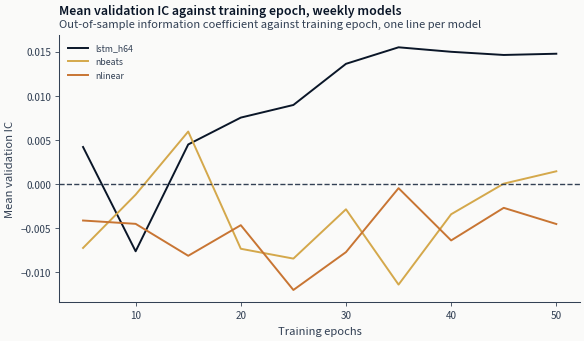

In [16]:
curves = pl.concat(
    [
        frame.select("config", "epoch", "ic_mean")
        for frame in (
            pytorch_result.get("all_learning_curves"),
            darts_result.get("all_learning_curves"),
        )
        if frame is not None and frame.height > 0
    ],
    how="vertical",
).sort("config", "epoch")

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
config_names = curves.get_column("config").unique(maintain_order=True).to_list()
# `ml4t_palette` returns a list of that many colours, so it is called once and indexed.
palette = ml4t_palette(len(config_names), categorical=True)
for index, config_name in enumerate(config_names):
    series = curves.filter(pl.col("config") == config_name)
    ax.plot(
        series.get_column("epoch").to_list(),
        series.get_column("ic_mean").to_list(),
        lw=1.4,
        color=palette[index],
        label=config_name,
    )
ax.axhline(0.0, color=COLORS["neutral"], ls="--", lw=1.0)
ax.set_xlabel("Training epochs")
ax.set_ylabel("Mean validation IC")
ax.legend(frameon=False, fontsize=7)
add_message_title(
    ax,
    "Mean validation IC against training epoch, weekly models",
    subtitle="Out-of-sample information coefficient against training epoch, one line per model",
)
# The alt text reads the frame rather than asserting a shape, so a panel described as turning
# over when it does not is a claim the data refutes.
_peaks = (
    curves.group_by("config")
    .agg(
        peak_epoch=pl.col("epoch").sort_by("ic_mean", descending=True).first(),
        last_epoch=pl.col("epoch").max(),
        first_epoch=pl.col("epoch").min(),
    )
    .with_columns(
        interior=pl.col("peak_epoch").is_between(
            pl.col("first_epoch"), pl.col("last_epoch"), closed="none"
        )
    )
)
_n_interior = int(_peaks.get_column("interior").sum())
show_with_alt(
    fig,
    "Line chart of mean validation information coefficient against training epoch, one line per "
    "weekly configuration, with a dashed line at zero. Counted from the underlying frame, "
    f"{_n_interior} of {_peaks.height} configurations reach their highest information "
    "coefficient at an epoch that is neither the first nor the last, which is what an interior "
    "optimum looks like.",
)

## Reading the summary table

**Every number in it is a maximum.** Each fit is scored at ten checkpoints, and the row below
carries that configuration's best one - which is the same quantity the daily notebooks refuse to
report as a single result, because the maximum of ten draws is larger than any one of them
whether or not the model learned anything. The curve above is what the maximum was taken from,
and it is the honest object: read the row to see where a configuration got to, and the curve to
see whether getting there meant anything.

Two comparisons follow, and they answer different questions.

**Within the weekly grid**, direct regression against one-step forecasting is the comparison
this notebook was built for: same rows, same horizon, same lookback, two ways of writing the
prediction down. What the table cannot do is settle it. Each row is a maximum over that
configuration's own ten checkpoints, both sides are, and applying the same operation to both is
not the same as the bias cancelling - how far a maximum of ten sits above the quantity
underneath depends on how much those ten vary and how correlated they are, and a recurrent fit,
a linear map over a normalised window and a stack of forecasting blocks have no reason to agree
on either. So an ordering here is not evidence that the formulation did anything. Establishing
that would take a paired comparison of the two on the same decision dates with an interval
around the difference, which is what `15_model_analysis` does for the daily families and which
nothing in this notebook computes.

**Against the daily families**, the comparison is looser twice over. Those models are scored on
every session and these on Fridays only, so the two are measured over different sets of decision
dates; and the daily figure below is a mean over the validation period rather than a maximum
over checkpoints, so it is not the same statistic. A difference between the two blocks is a
difference in the experiment before it is a difference in the model, which is also why these
predictions stay out of the canonical backtest pool.

**What generalizes is the reframing.** Whether sampling to a coarser grid pays depends on how
much history the panel holds and how fast the signal decays, and a reader applying this to their
own data should expect the balance between the two costs to land differently.

In [17]:
print("\n" + "=" * 60)
print("Weekly sequence models: validation IC by formulation")
print("=" * 60)

# Collect DL results
all_results = []
for r in pytorch_result["grid_results"]:
    all_results.append(
        {
            "model": r["config_name"],
            "approach": "direct regression",
            "ic": r["best_ic"],
            "epoch": r["best_epoch"],
        }
    )
all_results.append(
    {
        "model": "nbeats (DARTS)",
        "approach": "1-step forecasting",
        "ic": darts_result["best_ic"],
        "epoch": darts_result["best_epoch"],
    }
)

results_df = pl.DataFrame(all_results).sort("ic", descending=True).rename({"ic": "best_ic"})
display(results_df)

# The daily families are read through the registry's own accessors. The three tables this needs
# are exactly what `load_training_runs`, `load_prediction_sets` and `load_prediction_metrics`
# return, and `ic_mean_daily` is the mean the metrics table already holds.


Weekly sequence models: validation IC by formulation


model,approach,best_ic,epoch
str,str,f64,i64
"""lstm_h64""","""direct regression""",0.015505,35
"""nbeats (DARTS)""","""1-step forecasting""",0.005956,15
"""nlinear""","""direct regression""",-0.00046,35


In [18]:
daily_runs = [
    frame
    for family in ("linear", "gbm", "tabular_dl")
    if (frame := load_training_runs(CASE_STUDY_ID, family=family, label=PRIMARY_LABEL)).height
]
if daily_runs:
    runs = pl.concat(daily_runs, how="vertical_relaxed")
    sets = load_prediction_sets(CASE_STUDY_ID, split="validation")
    metrics = load_prediction_metrics(CASE_STUDY_ID)
    if sets.height and metrics.height and "ic_mean_daily" in metrics.columns:
        baselines = (
            runs.select("training_hash", "family", "config_name", "label")
            .join(sets.select("training_hash", "prediction_hash"), on="training_hash", how="inner")
            .join(
                metrics.select("prediction_hash", "ic_mean_daily"),
                on="prediction_hash",
                how="inner",
            )
            .drop_nulls("ic_mean_daily")
            .sort("ic_mean_daily", descending=True)
            .head(5)
            .select("family", "config_name", "label", "ic_mean_daily")
        )
    else:
        baselines = pl.DataFrame()
else:
    baselines = pl.DataFrame()

if baselines.height:
    print("\nDaily families on the same label, mean validation IC over the period:")
    display(baselines)
else:
    # Said rather than skipped. The paragraph above promises this comparison, and a cell that
    # prints nothing when the daily families have not been registered yet leaves the reader
    # looking for a table that was never going to appear.
    print(
        "\nNo daily linear, gbm or tabular_dl runs are registered for "
        f"{PRIMARY_LABEL} in this run log, so the second comparison above has nothing to make. "
        "Run 06_linear, 07_gbm and 08_tabular_dl first."
    )


Daily families on the same label, mean validation IC over the period:


family,config_name,label,ic_mean_daily
str,str,str,f64
"""gbm""","""leaves_63_mae""","""fwd_ret_5d""",0.034473
"""gbm""","""leaves_63_mae""","""fwd_ret_5d""",0.033915
"""gbm""","""leaves_63_mae""","""fwd_ret_5d""",0.033877
"""gbm""","""leaves_63_mae""","""fwd_ret_5d""",0.033264
"""gbm""","""leaves_63_huber""","""fwd_ret_5d""",0.033178
